# NB-01 · Data Loading Diagnostics
Verify raw `.npy` artifact loading: shapes, dtypes, NaN/Inf contamination, value ranges, and basic visualizations.

**Checks covered**
1. File existence
2. Shapes & dtypes
3. NaN / Inf scan
4. Complex value range (primary, secondaries, interferograms)
5. Parameter value ranges per channel
6. Spatial thumbnails

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

REPO_ROOT    = Path("../..").resolve()
DATASET_PATH = Path("/ste/rnd/User/vice_vi/Dataset/clean_dataset")
PARAMS_PATH  = DATASET_PATH / "params" / "params_sig_k5" / "parameters_sig_k5.npy"
DATA_DIR     = DATASET_PATH / "data"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root : {REPO_ROOT}")
print(f"Dataset   : {DATASET_PATH}")

Repo root : /ste/rnd/User/vice_vi/DLR-TomoSAR
Dataset   : /ste/rnd/User/vice_vi/Dataset/clean_dataset


## 1 · File discovery

In [2]:
with open(DATA_DIR / "dataset.json") as f:
    layout = json.load(f)

print(json.dumps(layout, indent=2))

files = {
    "primary"       : next(DATA_DIR.glob("primary_*.npy")),
    "secondaries"   : next(DATA_DIR.glob("secondaries_*.npy")),
    "interferograms": next(DATA_DIR.glob("interferograms_*.npy")),
    "params"        : PARAMS_PATH,
}

print("\nLocated files:")
for k, p in files.items():
    exists = "✓" if p.exists() else "✗ MISSING"
    print(f"  {exists}  {k:<18s}  {p}")

{
  "global_crop": [
    1000,
    16000,
    500,
    4000
  ],
  "dataset_type": "FSAR",
  "tomogram_tag": "1000a16000a500a4000_dtmf_Xtomo_id2X",
  "parameter_tag": "1000a16000a500a4000_1_Xparams_id2X",
  "artifacts": {
    "tomogram_full": "tomogram_full_1000a16000a500a4000_1_Xparams_id2X.npy",
    "tomogram_reduced": "tomogram_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy",
    "dem_full": "dem_full_1000a16000a500a4000_1_Xparams_id2X.npy",
    "dem_reduced": "dem_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy",
    "primary_reduced": "primary_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy",
    "secondaries_reduced": "secondaries_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy",
    "interferograms_reduced": "interferograms_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy"
  }
}

Located files:
  ✓  primary             /ste/rnd/User/vice_vi/Dataset/clean_dataset/data/primary_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy
  ✓  secondaries         /ste/rnd/User/vice_vi/Dataset/cl

## 2 · Shapes & dtypes

In [3]:
arrays = {k: np.load(p, mmap_mode='r') for k, p in files.items()}

print(f"{'Name':<20s}  {'Shape':<35s}  {'Dtype':<12s}  {'Bytes (MB)':>10s}")
print("-" * 85)
for name, arr in arrays.items():
    mb = arr.nbytes / 1e6
    print(f"  {name:<18s}  {str(arr.shape):<35s}  {str(arr.dtype):<12s}  {mb:>10.1f}")

Name                  Shape                                Dtype         Bytes (MB)
-------------------------------------------------------------------------------------
  primary             (15000, 3500)                        complex64          420.0
  secondaries         (4, 15000, 3500)                     complex64         1680.0
  interferograms      (4, 15000, 3500)                     complex64         1680.0
  params              (15, 15000, 3500)                    float32           3150.0


## 3 · NaN / Inf scan

In [4]:
SAMPLE_AZ = slice(1000, 1512)   # 512 rows to keep it fast

issues = []
for name, arr in arrays.items():
    chunk = np.array(arr[..., SAMPLE_AZ, :])   # load a slice into RAM
    flat  = chunk.view(np.float32) if np.iscomplexobj(chunk) else chunk
    n_nan = int(np.isnan(flat).sum())
    n_inf = int(np.isinf(flat).sum())
    status = "OK" if (n_nan == 0 and n_inf == 0) else "⚠ BAD"
    print(f"  {status}  {name:<20s}  NaN={n_nan:>8d}  Inf={n_inf:>8d}")
    if n_nan > 0 or n_inf > 0:
        issues.append(name)

if issues:
    print(f"\n⚠ WARNING: NaN/Inf found in: {issues}")
else:
    print("\n✓ No NaN / Inf detected in sampled region.")

  OK  primary               NaN=       0  Inf=       0
  OK  secondaries           NaN=       0  Inf=       0
  OK  interferograms        NaN=       0  Inf=       0
  OK  params                NaN=       0  Inf=       0

✓ No NaN / Inf detected in sampled region.


## 4 · Complex value ranges

In [5]:
for name in ("primary", "secondaries", "interferograms"):
    arr   = arrays[name]
    chunk = np.array(arr[0, SAMPLE_AZ, :]) if arr.ndim == 3 else np.array(arr[SAMPLE_AZ, :])
    mag   = np.abs(chunk)
    phase = np.angle(chunk)
    print(f"  {name}")
    print(f"    magnitude : min={mag.min():.4f}  max={mag.max():.4f}  mean={mag.mean():.4f}  std={mag.std():.4f}")
    print(f"    phase     : min={phase.min():.4f}  max={phase.max():.4f}  (should be within ±π)")
    if phase.min() < -np.pi - 0.01 or phase.max() > np.pi + 0.01:
        print(f"    ⚠ Phase out of [-π, π] range!")
    print()

  primary
    magnitude : min=0.0000  max=8.2806  mean=0.0747  std=0.0998
    phase     : min=-3.1416  max=3.1416  (should be within ±π)

  secondaries
    magnitude : min=0.0000  max=8.3930  mean=0.0753  std=0.1013
    phase     : min=-3.1416  max=3.1416  (should be within ±π)

  interferograms
    magnitude : min=0.0000  max=1.2500  mean=0.0750  std=0.0965
    phase     : min=-3.1416  max=3.1415  (should be within ±π)



## 5 · Parameter value ranges per channel

In [6]:
params = np.array(arrays["params"][..., SAMPLE_AZ, :], dtype=np.float32)
C      = params.shape[0]
n_gauss = C // 3

print(f"Params shape : {params.shape}  → {n_gauss} Gaussians × 3 params (a, μ, σ)")
print()
print(f"  {'Ch':>3s}  {'Role':<8s}  {'Min':>10s}  {'Max':>10s}  {'Mean':>10s}  {'Std':>10s}  {'NaN':>6s}")
print("  " + "-" * 65)
roles = ["amp", "mu", "sigma"]
for ch in range(C):
    p    = params[ch]
    role = roles[ch % 3]
    n_nan = int(np.isnan(p).sum())
    print(f"  {ch:>3d}  {role:<8s}  {p.min():>10.4f}  {p.max():>10.4f}  {np.nanmean(p):>10.4f}  {np.nanstd(p):>10.4f}  {n_nan:>6d}")

Params shape : (15, 512, 3500)  → 5 Gaussians × 3 params (a, μ, σ)

   Ch  Role             Min         Max        Mean         Std     NaN
  -----------------------------------------------------------------
    0  amp           0.0000    146.9407      0.3308      1.6058       0
    1  mu          -20.0000     45.7718     -5.3976      3.4180       0
    2  sigma         0.0000     50.0000      1.3888      1.6258       0
    3  amp           0.0000     23.9121      0.0605      0.2996       0
    4  mu          -17.3154     56.5101     -1.5143      4.3559       0
    5  sigma         0.0000     50.0000      0.5351      1.1235       0
    6  amp           0.0000     23.6045      0.0197      0.1815       0
    7  mu          -14.6309     67.2483      1.4626      6.8648       0
    8  sigma         0.0000     50.0000      0.1976      1.2265       0
    9  amp           0.0000     24.2284      0.0273      0.2345       0
   10  mu          -13.2886     77.3154      2.6468     10.8862       0


## 6 · Spatial thumbnails

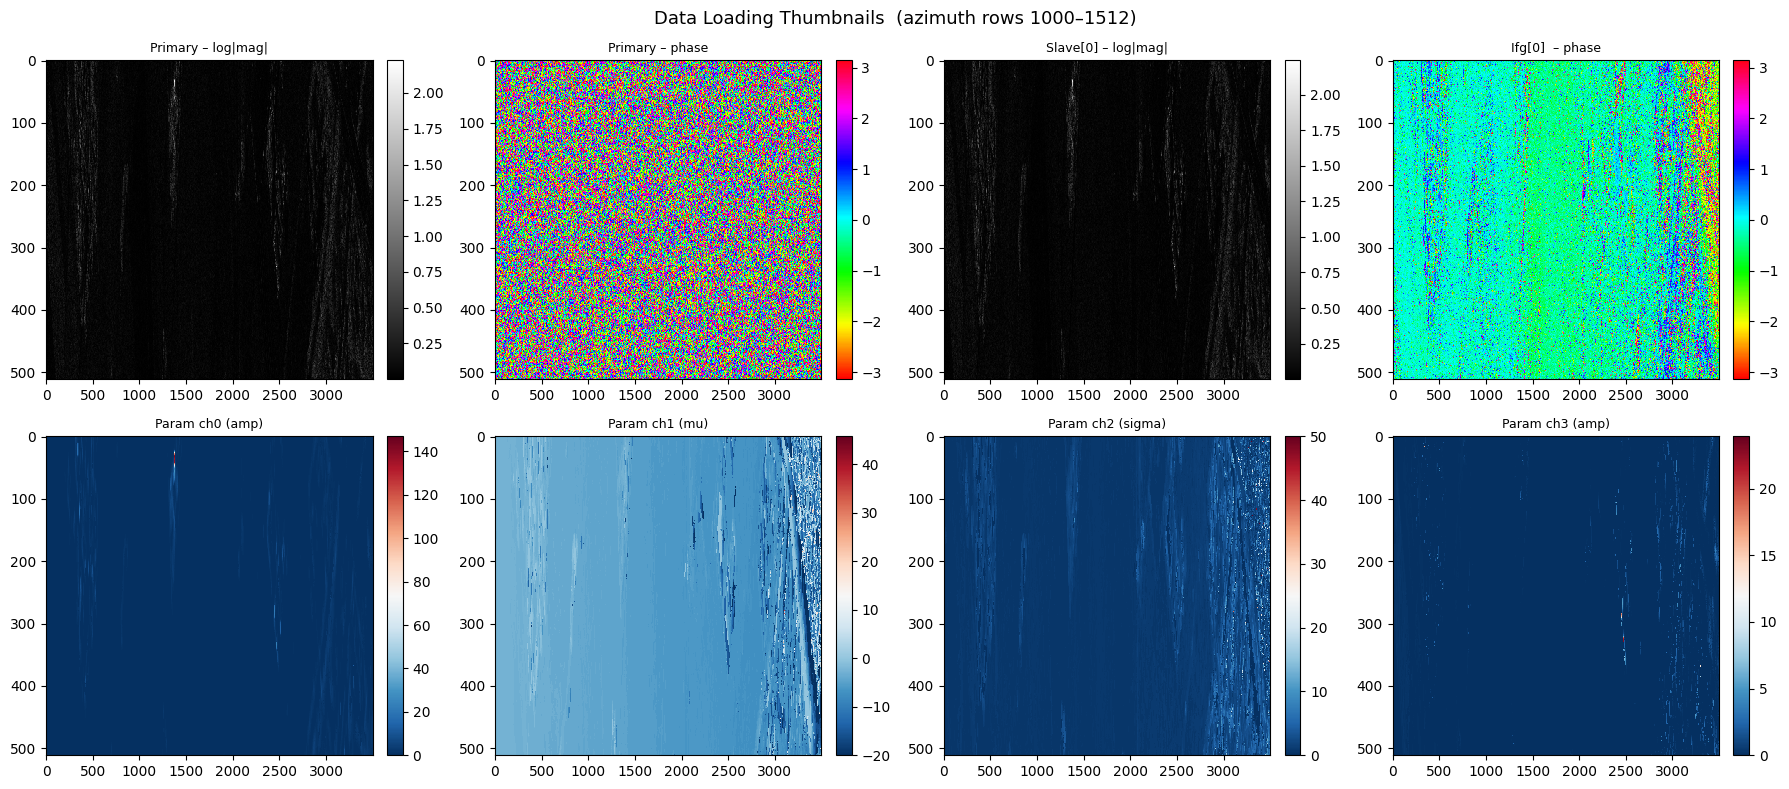

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Data Loading Thumbnails  (azimuth rows 1000–1512)", fontsize=13)

def show(ax, img, title, cmap="gray", vmin=None, vmax=None):
    im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest")
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

prim   = np.array(arrays["primary"][SAMPLE_AZ, :])
second = np.array(arrays["secondaries"][0, SAMPLE_AZ, :])
ifg    = np.array(arrays["interferograms"][0, SAMPLE_AZ, :])

show(axes[0,0], np.log1p(np.abs(prim)),   "Primary – log|mag|")
show(axes[0,1], np.angle(prim),            "Primary – phase",    cmap="hsv", vmin=-np.pi, vmax=np.pi)
show(axes[0,2], np.log1p(np.abs(second)), "Slave[0] – log|mag|")
show(axes[0,3], np.angle(ifg),            "Ifg[0]  – phase",    cmap="hsv", vmin=-np.pi, vmax=np.pi)

for i in range(4):
    role = roles[i % 3]
    show(axes[1,i], params[i, :, :],   f"Param ch{i} ({role})", cmap="RdBu_r")

plt.tight_layout()
plt.show()

## 7 · Parameter histogram per role

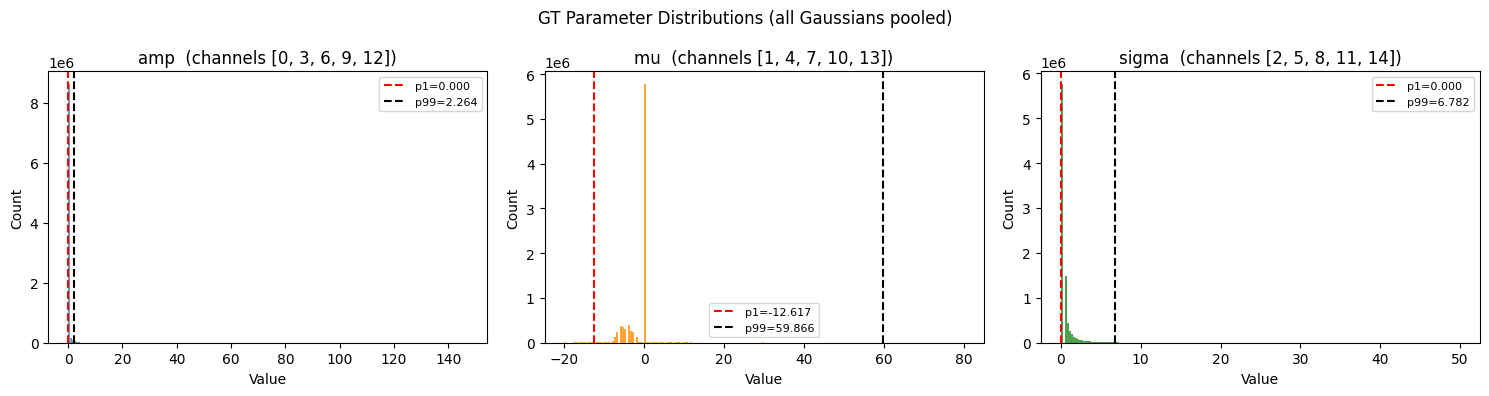

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("GT Parameter Distributions (all Gaussians pooled)", fontsize=12)

role_colors = {"amp": "steelblue", "mu": "darkorange", "sigma": "forestgreen"}
for ci, role in enumerate(roles):
    ch_indices = [ci + 3*k for k in range(n_gauss)]
    values = params[ch_indices].ravel()
    values = values[np.isfinite(values)]
    axes[ci].hist(values, bins=200, color=role_colors[role], alpha=0.8)
    axes[ci].set_title(f"{role}  (channels {ch_indices})")
    axes[ci].set_xlabel("Value")
    axes[ci].set_ylabel("Count")
    p1, p99 = np.percentile(values, [1, 99])
    axes[ci].axvline(p1,  color='red',   linestyle='--', label=f'p1={p1:.3f}')
    axes[ci].axvline(p99, color='black', linestyle='--', label=f'p99={p99:.3f}')
    axes[ci].legend(fontsize=8)

plt.tight_layout()
plt.show()